In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway

In [7]:
sns.set(style="whitegrid")
pd.options.display.float_format = '{:,.2f}'.format

# Load cleaned CSVs
benin = pd.read_csv('../data/benin_clean.csv', parse_dates=['Timestamp'])
sierra = pd.read_csv('../data/sierraleone_clean.csv', parse_dates=['Timestamp'])
togo = pd.read_csv('../data/togo_clean.csv', parse_dates=['Timestamp'])

# Tag country column
benin['country'] = 'Benin'
sierra['country'] = 'SierraLeone'
togo['country'] = 'Togo'

# quick sanity check
for name, df in [('Benin', benin), ('SierraLeone', sierra), ('Togo', togo)]:
    print(name, df.shape)


Benin (525600, 20)
SierraLeone (525600, 20)
Togo (516349, 20)


In [8]:
# Combine all three datasets into one DataFrame
combined = pd.concat([benin, sierra, togo], ignore_index=True)

# Keep only relevant columns for analysis
cols_of_interest = ['Timestamp', 'GHI', 'DNI', 'DHI', 'country']
combined = combined[cols_of_interest]

# Basic info check
print("Combined dataset shape:", combined.shape)
print("\nSummary of records by country:")
print(combined['country'].value_counts())

# Display sample
combined.head()


Combined dataset shape: (1567549, 5)

Summary of records by country:
country
Benin          525600
SierraLeone    525600
Togo           516349
Name: count, dtype: int64


,Timestamp,GHI,DNI,DHI,country
0,2021-08-09 00:01:00,-1.20,-0.20,-1.10,Benin
1,2021-08-09 00:02:00,-1.10,-0.20,-1.10,Benin
2,2021-08-09 00:03:00,-1.10,-0.20,-1.10,Benin
3,2021-08-09 00:04:00,-1.10,-0.10,-1.00,Benin
4,2021-08-09 00:05:00,-1.00,-0.10,-1.00,Benin


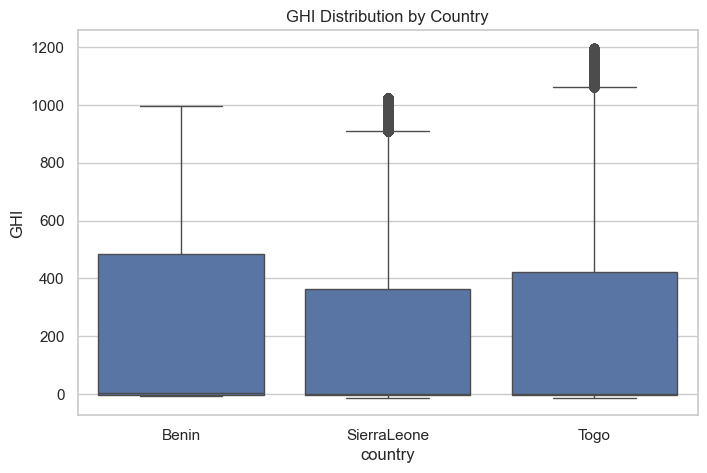

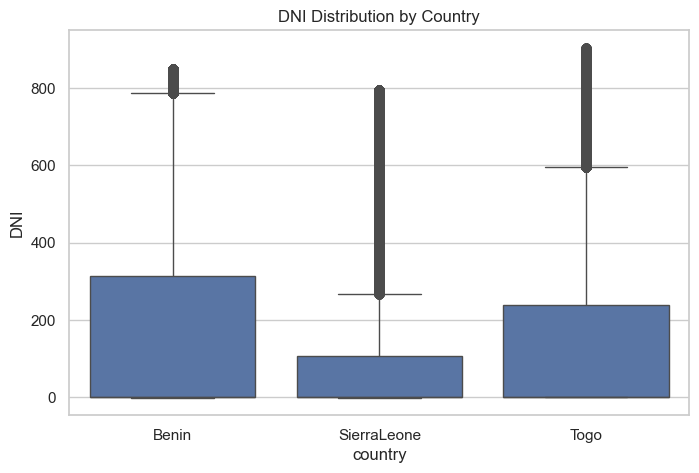

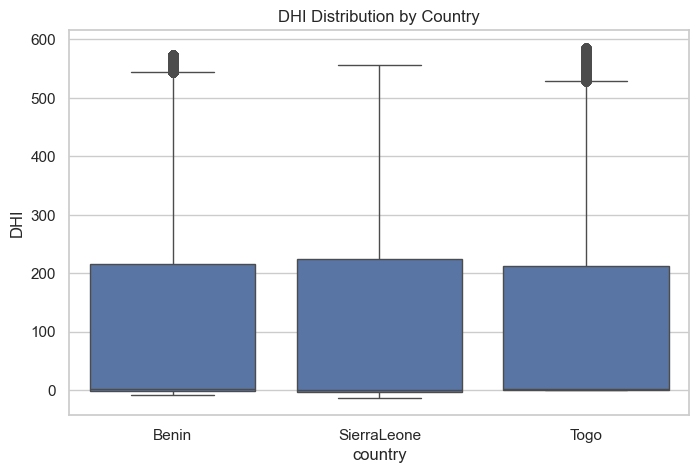

Summary Table (mean, median, std):


GHI                  DNI                  DHI              
              mean median    std   mean median    std   mean median    std
country                                                                   
Benin       239.98   1.80 329.68 166.93  -0.10 261.02 114.96   1.60 157.43
SierraLeone 201.11   0.30 295.89 115.96  -0.10 217.28 113.22  -0.10 157.35
Togo        223.86   0.50 317.31 147.98   0.00 247.68 112.78   1.50 151.57

In [9]:
# Set style
sns.set(style="whitegrid")

# Boxplots for GHI, DNI, DHI
metrics = ['GHI', 'DNI', 'DHI']

for metric in metrics:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='country', y=metric, data=combined)
    plt.title(f'{metric} Distribution by Country')
    plt.show()

# Summary table
summary = combined.groupby('country')[metrics].agg(['mean', 'median', 'std'])
print("Summary Table (mean, median, std):")
display(summary)


In [10]:


# Separate GHI values by country
ghi_benin = combined[combined['country'] == 'Benin']['GHI']
ghi_sierra = combined[combined['country'] == 'SierraLeone']['GHI']
ghi_togo = combined[combined['country'] == 'Togo']['GHI']

# Run one-way ANOVA
anova_result = f_oneway(ghi_benin, ghi_sierra, ghi_togo)

print("ANOVA Result for GHI:")
print(f"F-statistic: {anova_result.statistic:.4f}")
print(f"P-value: {anova_result.pvalue:.4e}")


ANOVA Result for GHI:
F-statistic: 2026.2967
P-value: 0.0000e+00


In [13]:
# Set plotting style
sns.set(style="whitegrid")
pd.options.display.float_format = '{:,.2f}'.format

# Load cleaned CSVs
benin_df = pd.read_csv('../data/benin_clean.csv', parse_dates=['Timestamp'])
sl_df = pd.read_csv('../data/sierraleone_clean.csv', parse_dates=['Timestamp'])
togo_df = pd.read_csv('../data/togo_clean.csv', parse_dates=['Timestamp'])

# Add a column for country name
benin_df['country'] = 'Benin'
sl_df['country'] = 'SierraLeone'
togo_df['country'] = 'Togo'

# Select only the relevant columns for comparison
benin_df = benin_df[['Timestamp', 'GHI', 'DNI', 'DHI', 'country']]
sl_df = sl_df[['Timestamp', 'GHI', 'DNI', 'DHI', 'country']]
togo_df = togo_df[['Timestamp', 'GHI', 'DNI', 'DHI', 'country']]

# Combine all datasets
combined_df = pd.concat([benin_df, sl_df, togo_df], ignore_index=True)

# Check combined data
print("Combined dataset shape:", combined_df.shape)
print("\nSummary of records by country:")
print(combined_df.groupby('country').count()['GHI'])
combined_df.head()

Combined dataset shape: (1567549, 5)

Summary of records by country:
country
Benin          525600
SierraLeone    525600
Togo           516349
Name: GHI, dtype: int64


,Timestamp,GHI,DNI,DHI,country
0,2021-08-09 00:01:00,-1.20,-0.20,-1.10,Benin
1,2021-08-09 00:02:00,-1.10,-0.20,-1.10,Benin
2,2021-08-09 00:03:00,-1.10,-0.20,-1.10,Benin
3,2021-08-09 00:04:00,-1.10,-0.10,-1.00,Benin
4,2021-08-09 00:05:00,-1.00,-0.10,-1.00,Benin


Average GHI by Country:
country
Benin         239.98
SierraLeone   201.11
Togo          223.86
Name: GHI, dtype: float64


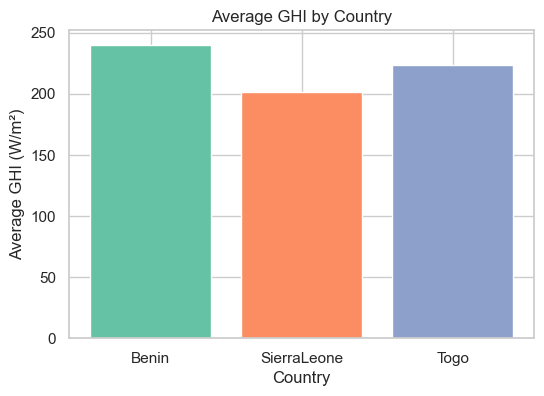

In [18]:
# Calculate average GHI by country
avg_ghi = combined_df.groupby('country')['GHI'].mean()
print("Average GHI by Country:")
print(avg_ghi)

# Improved bar plot to remove warning
avg_ghi_df = avg_ghi.reset_index()
avg_ghi_df.columns = ['country', 'GHI']

plt.figure(figsize=(6,4))
plt.bar(avg_ghi_df['country'], avg_ghi_df['GHI'], color=['#66c2a5','#fc8d62','#8da0cb'])
plt.title("Average GHI by Country")
plt.ylabel("Average GHI (W/m²)")
plt.xlabel("Country")
plt.show()


### Key Observations

- **Benin** has the **highest average and median GHI** (≈240 W/m²), indicating it has the **strongest solar potential** among the three countries.
- **Sierra Leone** shows the **lowest average GHI** (≈201 W/m²) and a **moderate variability**, suggesting less consistent solar energy availability.
- **Togo** has an **intermediate GHI** (≈224 W/m²) but shows **relatively stable irradiance**, which could make it attractive for solar farms requiring predictable output.
